In [66]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import numpy as np
import os
from tqdm import tqdm

import matplotlib.pyplot as plt
import random

from IPython.display import clear_output

device = 'cuda' if torch.cuda.is_available() else 'cpu'
# device = 'cpu'
device

'cuda'

In [67]:
STATE_SCALE = 10

In [183]:
class FRENetwork(nn.Module):
    def __init__(self, obs_len, num_heads=2, num_layers=2, reward_pairs_emb_dim=128):
        super().__init__()
        
        self.obs_len = obs_len
        self.reward_pairs_emb_dim = reward_pairs_emb_dim
        self.num_discrete_embeddings = 32
        
        self.encoder_transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                self.reward_pairs_emb_dim, 
                num_heads, 
                dim_feedforward=4*self.reward_pairs_emb_dim, 
                batch_first=True
            ),
            num_layers=num_layers
        )
        self.encoder_mean = nn.Linear(self.reward_pairs_emb_dim, self.reward_pairs_emb_dim)
        self.encoder_log_std = nn.Linear(self.reward_pairs_emb_dim, self.reward_pairs_emb_dim)

        self.state_embed = nn.Linear(self.obs_len, self.reward_pairs_emb_dim // 2)
        self.reward_embed = nn.Embedding(self.num_discrete_embeddings, self.reward_pairs_emb_dim // 2)

        self.reward_predict = nn.Sequential(
            nn.Linear(self.obs_len + self.reward_pairs_emb_dim, 512),
            nn.LayerNorm(512),
            nn.Mish(),
            # nn.Linear(512, 512),
            # nn.LayerNorm(512),
            # nn.Mish(),
            # nn.Linear(512, 512),
            # nn.LayerNorm(512),
            # nn.Mish(),
            nn.Linear(512, 1),
        )



    def get_transformer_encoding(self, states, rewards, pad_mask):  
        
        
        batch_size, num_anchors = states.shape[0], states.shape[1]
        
        if pad_mask is None:
            pad_mask = torch.zeros((batch_size, num_anchors), dtype=torch.bool, device=device)
        # pad_mask.shape = [batch, anchors]
        
        reward_values_idx = torch.floor(rewards * self.num_discrete_embeddings).int()
        reward_values_idx = torch.clip(reward_values_idx, 0, self.num_discrete_embeddings - 1)
        
        state_emb = self.state_embed(states)
        reward_emb = self.reward_embed(reward_values_idx.squeeze(-1))
        state_reward_emd = torch.concat((state_emb, reward_emb), dim=-1)
        
        w_pre = self.encoder_transformer(state_reward_emd, src_key_padding_mask=pad_mask) # [batch, anchors, emb_dim]
        
        
        valid_tokens = (~pad_mask).float()  # (B, T), converts True -> 0, False -> 1
        valid_tokens = valid_tokens.unsqueeze(-1)  # (B, T, 1)
        sum_embeddings = (w_pre * valid_tokens).sum(dim=1)  # Sum over sequence dimension
        w_pair_mean = sum_embeddings / valid_tokens.sum(dim=1)
        
        # w_pair_mean = w_pre.mean(axis=1)
        # print(w_pair_mean.shape)
        w_mean = self.encoder_mean(w_pair_mean)
        w_log_std = self.encoder_log_std(w_pair_mean)

        return w_mean, w_log_std # (batch_size, emb_dim)
    
    
    def get_reward_pred(self, w, reward_states): # Reward Pairs: [batch, reward_pairs, obs_dim + 1]
        z_expand = w.unsqueeze(1) # [batch, 1, emb_dim]
        z_expand = z_expand.repeat(1, reward_states.shape[1], 1)        
        
        w_and_obs = torch.concatenate([z_expand, reward_states], axis=-1)
        
        reward_pred = self.reward_predict(w_and_obs)
        
        return reward_pred # [batch, reward_pairs]
        

In [184]:
fixed_anchors = []
a, b = 0.25, 0.25
# x_coords = [-a + 2*a/3*n for n in range(4)]
x_coords = torch.linspace(-0.275, 0.275, 4)
# y_coords = [-b + 2*b/3*n for n in range(4)]
y_coords = torch.linspace(-0.275, 0.275, 4)
for x1 in x_coords:
    for x2 in y_coords:
        fixed_anchors.append([x2, x1])

In [185]:
def get_training_data(batch_size, min_num_anchors, max_num_anchors, num_states, from_fixed_anchors=False):
    assert min_num_anchors <= max_num_anchors <= num_states
    # anchors_idx = torch.randint(0, observations.shape[0], (batch_size, num_anchors,))
    # other_idx = torch.randint(0, observations.shape[0], (batch_size, num_states - num_anchors,))
    # anchors = observations[anchors_idx]
    # non_anchors = observations[other_idx]
    
    anchors = torch.rand((batch_size, max_num_anchors, 2)) * 0.6 - 0.3
    if from_fixed_anchors:
        anchors = torch.tensor(fixed_anchors).unsqueeze(0).repeat(batch_size, 1, 1)
    
    non_anchors = torch.rand((batch_size, num_states - max_num_anchors, 2)) * 0.6 - 0.3
    
    anchors = anchors * STATE_SCALE
    non_anchors = non_anchors * STATE_SCALE
    
    
    # print(anchors.shape, non_anchors.shape)

    all_states = torch.concatenate((anchors, non_anchors), dim=1)
    all_states.shape

    rewards = torch.zeros((batch_size, num_states, 1), dtype=torch.float32)
    
    candidates = [0.01, 0.25, 0.5, 1.]
    anchors_rewards = torch.tensor(candidates).unsqueeze(0).repeat(batch_size, 1)
    anchors_rewards = anchors_rewards[
        torch.arange(batch_size).unsqueeze(1).expand(-1, max_num_anchors), 
        torch.randint(0, len(candidates), size=(batch_size,max_num_anchors))
    ]
    
    # rewards[:, :max_num_anchors] = 1
    rewards[:, :max_num_anchors] = anchors_rewards.unsqueeze(-1)
    rewards[:, max_num_anchors:] = 0
    
    pad_mask = torch.ones((batch_size, max_num_anchors), dtype=torch.bool)
    for i in range(batch_size):
        num_anchors = random.randint(min_num_anchors, max_num_anchors)
        anchors   [i, num_anchors:max_num_anchors] = 0
        all_states[i, num_anchors:max_num_anchors] = 0
        rewards   [i, num_anchors:max_num_anchors] = 0
        pad_mask  [i, :num_anchors] = False
        

    anchors_rewards = rewards[:, :max_num_anchors]
    return (anchors, anchors_rewards, pad_mask), (all_states, rewards)


(anchors, anchors_rewards, pad_mask), (all_states, rewards) = get_training_data(
    batch_size=256, 
    min_num_anchors=4,
    max_num_anchors=7,
    num_states=128)

In [186]:
fre_network = FRENetwork(obs_len=2).to(device)
optimimizer = torch.optim.Adam(fre_network.parameters(), lr=0.001)

steps = 100000

losses = []
pred_losses = []

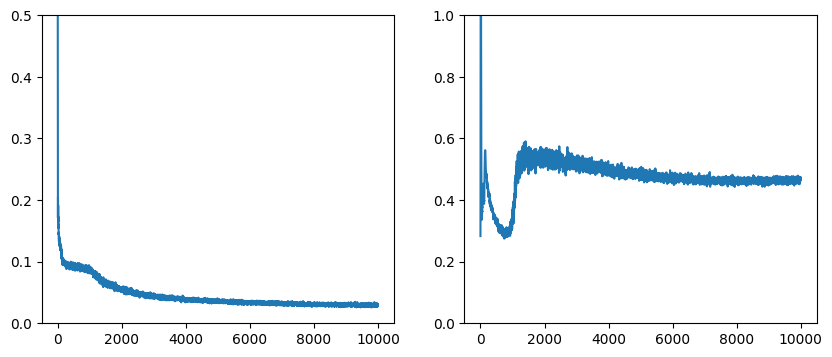

 10%|█         | 10028/100000 [01:31<13:36, 110.20it/s]


KeyboardInterrupt: 

In [187]:
min_num_anchors = 8
max_num_anchors = 8

for i in tqdm(range(steps)):
    
    (anchors, anchors_rewards, pad_mask), (all_states, rewards) = get_training_data(
        batch_size=256, 
        min_num_anchors=min_num_anchors, 
        max_num_anchors=max_num_anchors,
        num_states=16
    )
    anchors = anchors.to(device)
    anchors_rewards = anchors_rewards.to(device)
    pad_mask = pad_mask.to(device)
    all_states = all_states.to(device)
    rewards = rewards.to(device)
    
    w_mean, w_log_std = fre_network.get_transformer_encoding(anchors, anchors_rewards, pad_mask=pad_mask)
    
    
    # Calculate the loss:
    
    w = w_mean + torch.normal(0, 1, size=w_mean.shape, device=device) * torch.exp(w_log_std)
    # w = w_mean
    rewards_pred = fre_network.get_reward_pred(w, all_states)
    # rewards_pred = torch.clip(rewards_pred, 0, 1)
    
    is_anchor = (rewards != 0)
    
    # reward_pred_loss = ((rewards_pred[ is_anchor] - 1)**2).mean() + \
    #                    ((rewards_pred[~is_anchor] - 0)**2).mean() * 0.5
                       
    reward_pred_loss = ((rewards_pred[ is_anchor] - rewards[is_anchor])**2).mean()                       
    
    
    kl_loss = -0.5 * (1 + 2*w_log_std - w_mean**2 - torch.exp(w_log_std)**2).mean()
    reward_kl_loss = reward_pred_loss + kl_loss * 0.01
    loss = reward_kl_loss
    
    optimimizer.zero_grad()
    loss.backward()
    optimimizer.step()
    
    losses.append(loss.item())
    pred_losses.append(kl_loss.item())
    
    # break
    if i % 200 == 0:
        clear_output(True)
        fig, axs = plt.subplots(1, 2, figsize=(10, 4))
        
        axs[0].plot(losses)
        axs[0].set_ylim([0, 0.5])
        
        axs[1].plot(pred_losses)
        axs[1].set_ylim([0, 1])
        
    
        plt.show()
        
        

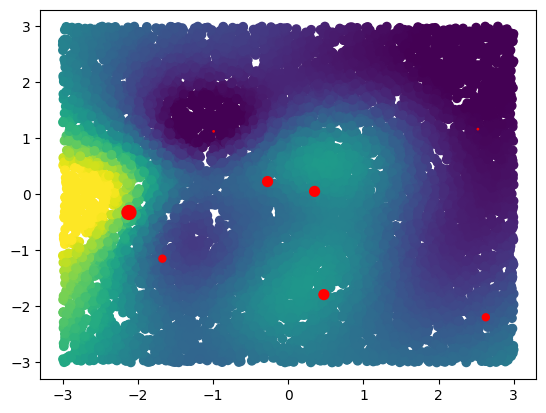

In [250]:
num_anchors = 8
min_num_anchors, max_num_anchors = num_anchors, num_anchors
(anchors, anchors_rewards, pad_mask), (all_states, rewards) = get_training_data(
    batch_size=1, 
    min_num_anchors=min_num_anchors, 
    max_num_anchors=max_num_anchors,
    num_states=10000
)
anchors = anchors.to(device)
anchors_rewards = anchors_rewards.to(device)
pad_mask = pad_mask.to(device)
# anchors = torch.zeros_like(anchors).to(device)
all_states = all_states.to(device)
rewards = rewards.to(device)


w_mean, w_log_std = fre_network.get_transformer_encoding(anchors, anchors_rewards, pad_mask)   

# Calculate the loss:

w = w_mean + torch.normal(0, 1, size=w_mean.shape, device=device) * torch.exp(w_log_std)
# w = torch.normal(0, 1, (1, 128), device=device) * 0.5

rewards_pred = fre_network.get_reward_pred(w, all_states)

# reward_pred_loss = ((rewards_pred - rewards)**2).mean()
# kl_loss = -0.5 * (1 + w_log_std - w_mean**2 - torch.exp(w_log_std)).mean()
# reward_kl_loss = reward_pred_loss + kl_loss * 0.01
# loss = reward_kl_loss



plt.scatter(all_states[0, :, 0].cpu(), all_states[0, :, 1].cpu(), c=rewards_pred.detach().cpu(), vmin=0, vmax=1)
plt.scatter(anchors[0, :, 0].cpu(), anchors[0, :, 1].cpu(), c='red', s=anchors_rewards.reshape(-1).cpu()*100)

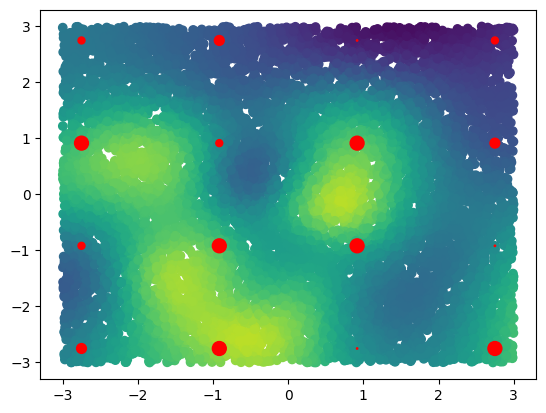

In [253]:
num_anchors = 16
min_num_anchors, max_num_anchors = num_anchors, num_anchors
(anchors, anchors_rewards, pad_mask), (all_states, rewards) = get_training_data(
    batch_size=1, 
    min_num_anchors=min_num_anchors, 
    max_num_anchors=max_num_anchors,
    num_states=10000,
    from_fixed_anchors=True
)
anchors = anchors.to(device)
anchors_rewards = anchors_rewards.to(device)
pad_mask = pad_mask.to(device)
# anchors = torch.zeros_like(anchors).to(device)
all_states = all_states.to(device)
rewards = rewards.to(device)


w_mean, w_log_std = fre_network.get_transformer_encoding(anchors, anchors_rewards, pad_mask)   

# Calculate the loss:

w = w_mean + torch.normal(0, 1, size=w_mean.shape, device=device) * torch.exp(w_log_std)
# w = torch.normal(0, 1, (1, 128), device=device) * 0.5

rewards_pred = fre_network.get_reward_pred(w, all_states)

# reward_pred_loss = ((rewards_pred - rewards)**2).mean()
# kl_loss = -0.5 * (1 + w_log_std - w_mean**2 - torch.exp(w_log_std)).mean()
# reward_kl_loss = reward_pred_loss + kl_loss * 0.01
# loss = reward_kl_loss



plt.scatter(all_states[0, :, 0].cpu(), all_states[0, :, 1].cpu(), c=rewards_pred.detach().cpu(), vmin=0, vmax=1)
plt.scatter(anchors[0, :, 0].cpu(), anchors[0, :, 1].cpu(), c='red', s=anchors_rewards.reshape(-1).cpu()*100)

---

100%|██████████| 1000/1000 [00:01<00:00, 587.68it/s]


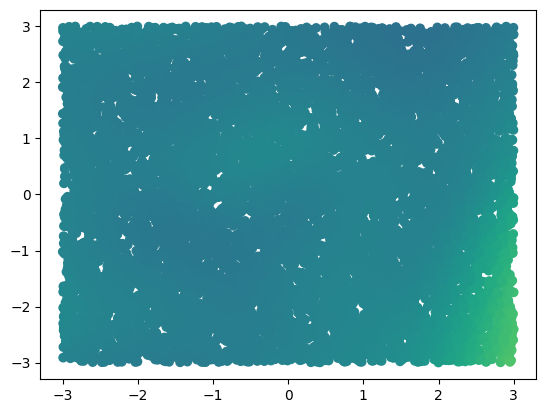

In [254]:
# num_anchors = 1
# min_num_anchors, max_num_anchors = num_anchors, num_anchors
min_num_anchors, max_num_anchors = 8, 8

(_, _, _), (all_states, _) = get_training_data(
    batch_size=1, 
    min_num_anchors=min_num_anchors, 
    max_num_anchors=max_num_anchors,
    num_states=10000
)
all_states = all_states.to(device)


r = []
for _  in tqdm(range(1000)):
    
    (anchors, anchors_rewards, _), (_, _) = get_training_data(
        batch_size=1, 
        min_num_anchors=min_num_anchors, 
        max_num_anchors=max_num_anchors,
        num_states=10000
    )
    
    anchors = anchors.to(device)
    anchors_rewards = anchors_rewards.to(device)

    with torch.no_grad():
        w_mean, w_log_std = fre_network.get_transformer_encoding(anchors, anchors_rewards, None)   
        w = w_mean + torch.normal(0, 1, size=w_mean.shape, device=device) * torch.exp(w_log_std)
        rewards_pred = fre_network.get_reward_pred(w, all_states)
    
    r.append(rewards_pred.flatten().cpu())
    
avg_reward = torch.stack(r).mean(dim=0)
plt.scatter(all_states[0, :, 0].cpu(), all_states[0, :, 1].cpu(), c=avg_reward.detach().cpu(), vmin=0, vmax=1)

In [255]:
all_means, all_vars = [], []

for  _ in tqdm(range(10000)):
    min_num_anchors = 1
    max_num_anchors = 1
    (anchors, rewards, pad_mask), (_, _) = get_training_data(
        batch_size=1, 
        min_num_anchors=min_num_anchors, 
        max_num_anchors=max_num_anchors,
        num_states=10
    )
    anchors = anchors.to(device)
    rewards = rewards.to(device)
    pad_mask = pad_mask.to(device)

    with torch.no_grad():
        w_mean, w_log_std = fre_network.get_transformer_encoding(anchors, rewards, pad_mask)   
        var = torch.exp(2*w_log_std)
    all_means.append(w_mean[0].cpu())
    all_vars.append(var[0].cpu())

emperical_mean = torch.stack(all_means).mean(dim=0).to(device)
# emperical_std = torch.stack(all_stds).mean(dim=0).to(device)

sigma_hat = (torch.stack(all_vars).to(device) + torch.stack(all_means).to(device)**2).mean(dim=0) - emperical_mean**2
emperical_std = sigma_hat ** 0.5

100%|██████████| 10000/10000 [00:08<00:00, 1217.10it/s]


100%|██████████| 1000/1000 [00:00<00:00, 1221.43it/s]


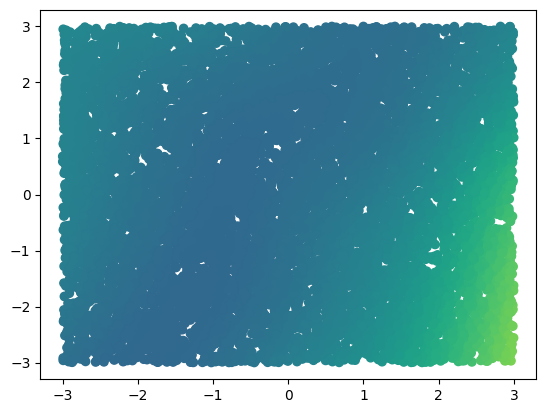

In [256]:
(_, _, _), (all_states, _) = get_training_data(
    batch_size=1, 
    min_num_anchors=1, 
    max_num_anchors=1,
    num_states=10000
)
all_states = all_states.to(device)


r = []
for _ in tqdm(range(1000)):
    w = emperical_mean  + torch.normal(0, 1, emperical_mean.shape, device=device) * emperical_std
    # w = torch.normal(0, 1, emperical_mean.shape, device=device)
    
    w = w.unsqueeze(0)

    with torch.no_grad():
        rewards_pred = fre_network.get_reward_pred(w, all_states)
        
    r.append(rewards_pred.flatten().cpu())
    
avg_reward = torch.stack(r).mean(dim=0)
plt.scatter(all_states[0, :, 0].cpu(), all_states[0, :, 1].cpu(), c=avg_reward.detach().cpu(), vmin=0, vmax=1)

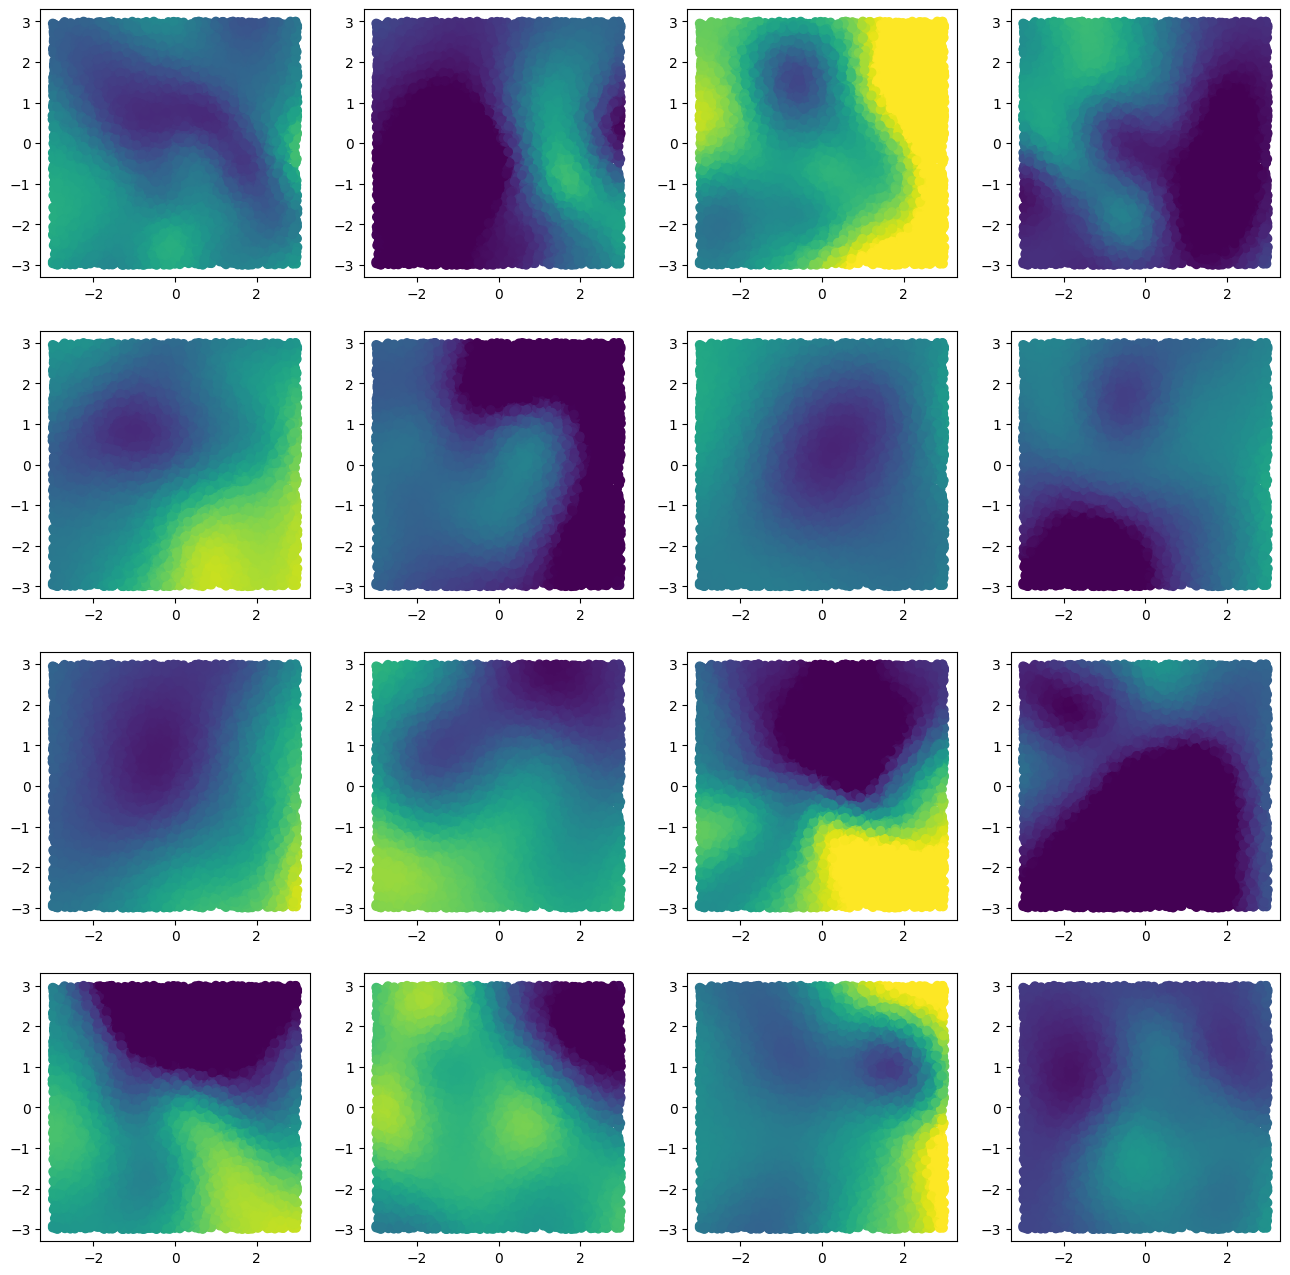

In [257]:
N = 4
fig, axs = plt.subplots(N, N, figsize=(4*N, 4*N))
axs = axs.flatten()
for i in range(N*N):
    axs[i].scatter(all_states[0, :, 0].cpu(), all_states[0, :, 1].cpu(), c=r[i].detach().cpu(), vmin=0, vmax=1)

In [268]:
a = torch.full((4, 2), 2.)
m = torch.tensor([
    [True, False],
    [False, True],
    [False, False],
    [True, True],
])

a[m] = torch.tensor([5., 6., 8., 9.])

tensor([[5., 2.],
        [2., 6.],
        [2., 2.],
        [8., 9.]])

In [269]:
torch.choo

0.25